In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [5]:
#Check missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum())
print(f"\nTotal rows: {df.shape[0]}")

Missing values before imputation:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Total rows: 6607


In [6]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [7]:
#Verify no more missing values
print("\nMissing values AFTER imputation:")
print(df.isnull().sum())


Missing values AFTER imputation:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [8]:
print(df.select_dtypes(include=['object', 'string']).columns)

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='str')


In [9]:
print(df["Teacher_Quality"].unique().tolist())
print(df["Parental_Education_Level"].unique().tolist())
print(df["Distance_from_Home"].unique().tolist())

['Medium', 'High', 'Low']
['High School', 'College', 'Postgraduate']
['Near', 'Moderate', 'Far']


In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df.shape)
print(df_encoded.shape)

(6607, 20)
(6607, 28)


In [11]:
threshold = df_encoded["Exam_Score"].median()
df_encoded["Pass_Fail"] = (df_encoded["Exam_Score"] >= threshold).astype(int)

In [12]:
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)


print("Data types:")
print(df_encoded.dtypes)

Data types:
Hours_Studied                            int64
Attendance                               int64
Sleep_Hours                              int64
Previous_Scores                          int64
Tutoring_Sessions                        int64
Physical_Activity                        int64
Exam_Score                               int64
Parental_Involvement_Low                 int64
Parental_Involvement_Medium              int64
Access_to_Resources_Low                  int64
Access_to_Resources_Medium               int64
Extracurricular_Activities_Yes           int64
Motivation_Level_Low                     int64
Motivation_Level_Medium                  int64
Internet_Access_Yes                      int64
Family_Income_Low                        int64
Family_Income_Medium                     int64
Teacher_Quality_Low                      int64
Teacher_Quality_Medium                   int64
School_Type_Public                       int64
Peer_Influence_Neutral                   int64
P

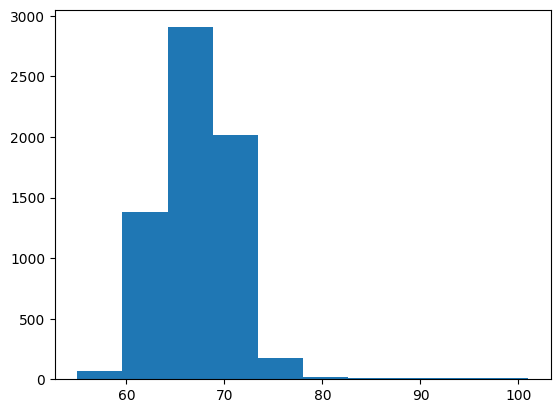

Mean: 67.23565914938702
Median: 67.0
Std: 3.890455781261732


In [13]:
import matplotlib.pyplot as plt

plt.hist(df_encoded["Exam_Score"])
plt.show()

print("Mean:", df_encoded["Exam_Score"].mean())
print("Median:", df_encoded["Exam_Score"].median())
print("Std:", df_encoded["Exam_Score"].std())

In [14]:
import seaborn as sns

In [15]:
top_features = df_encoded.corr()["Exam_Score"].abs().sort_values(ascending=False).index[1:6]

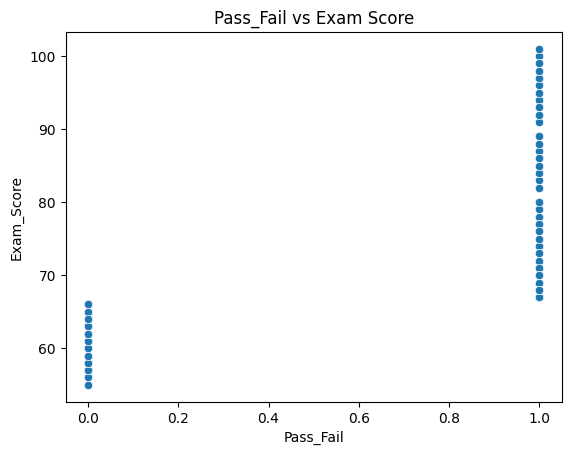

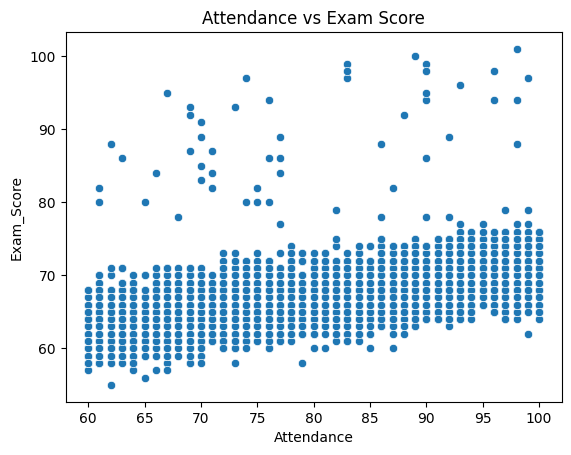

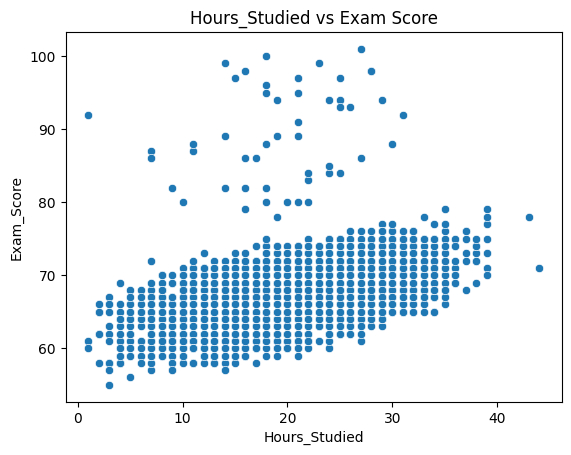

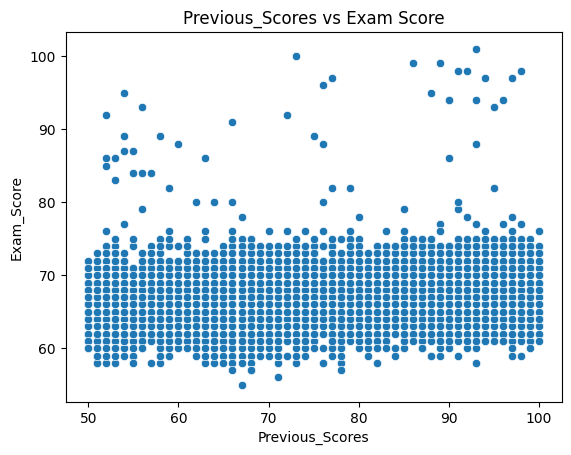

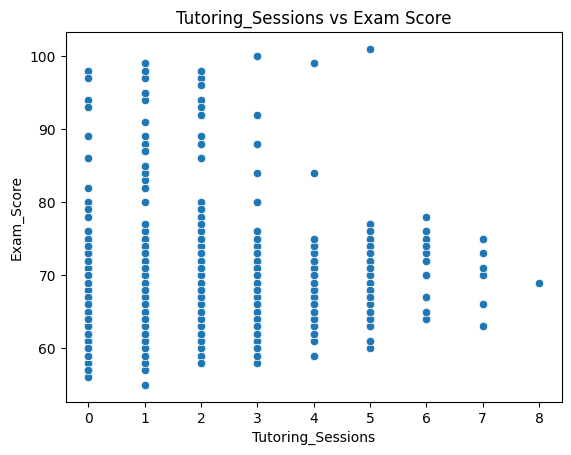

In [16]:
for col in top_features:
    plt.figure()
    sns.scatterplot(x=df_encoded[col], y=df_encoded["Exam_Score"])
    plt.title(f"{col} vs Exam Score")
    plt.show()

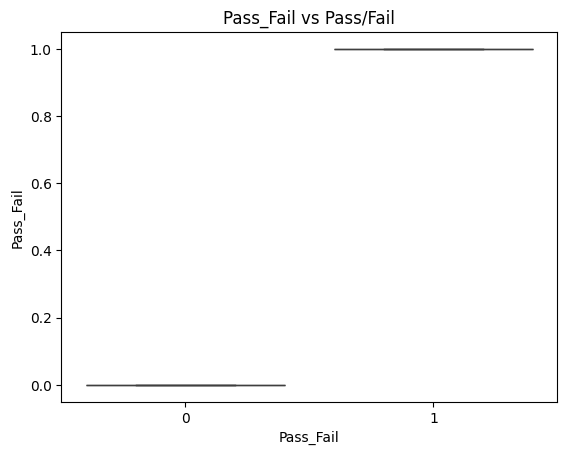

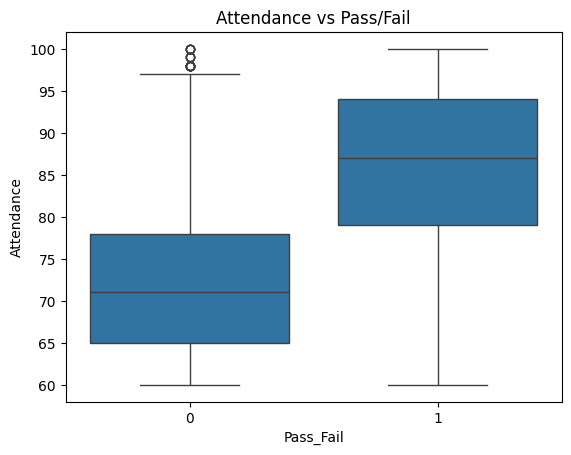

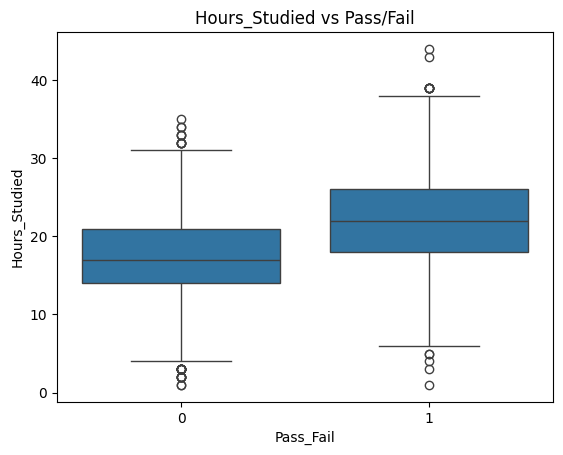

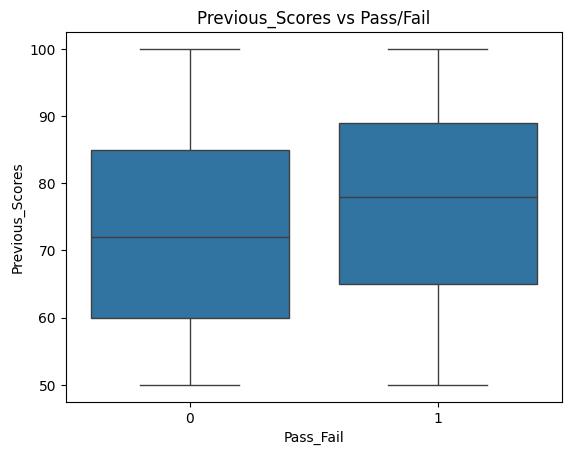

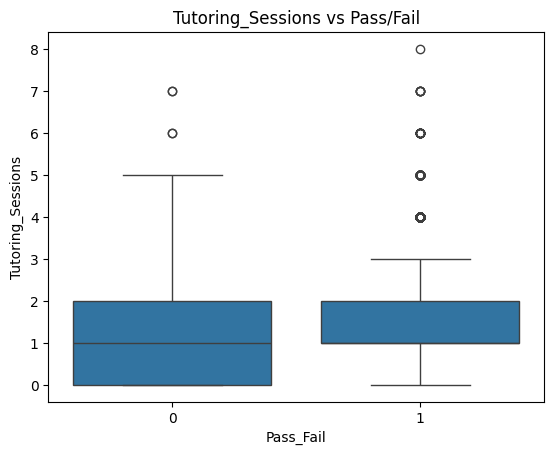

In [17]:
for col in top_features:
    plt.figure()
    sns.boxplot(x=df_encoded["Pass_Fail"], y=df_encoded[col])
    plt.title(f"{col} vs Pass/Fail")
    plt.show()

In [18]:
features = df_encoded.drop("Exam_Score", axis=1)

In [19]:
corr = features.corr()
print(corr)

                                       Hours_Studied  Attendance  Sleep_Hours  \
Hours_Studied                               1.000000   -0.009908     0.010977   
Attendance                                 -0.009908    1.000000    -0.015918   
Sleep_Hours                                 0.010977   -0.015918     1.000000   
Previous_Scores                             0.024846   -0.020186    -0.021750   
Tutoring_Sessions                          -0.014282    0.014324    -0.012216   
Physical_Activity                           0.004624   -0.022435    -0.000378   
Parental_Involvement_Low                    0.013395    0.014296     0.008250   
Parental_Involvement_Medium                 0.000856   -0.010021    -0.002207   
Access_to_Resources_Low                     0.012119    0.012798     0.020371   
Access_to_Resources_Medium                 -0.011730   -0.004356    -0.012259   
Extracurricular_Activities_Yes             -0.006017   -0.002222     0.001379   
Motivation_Level_Low        

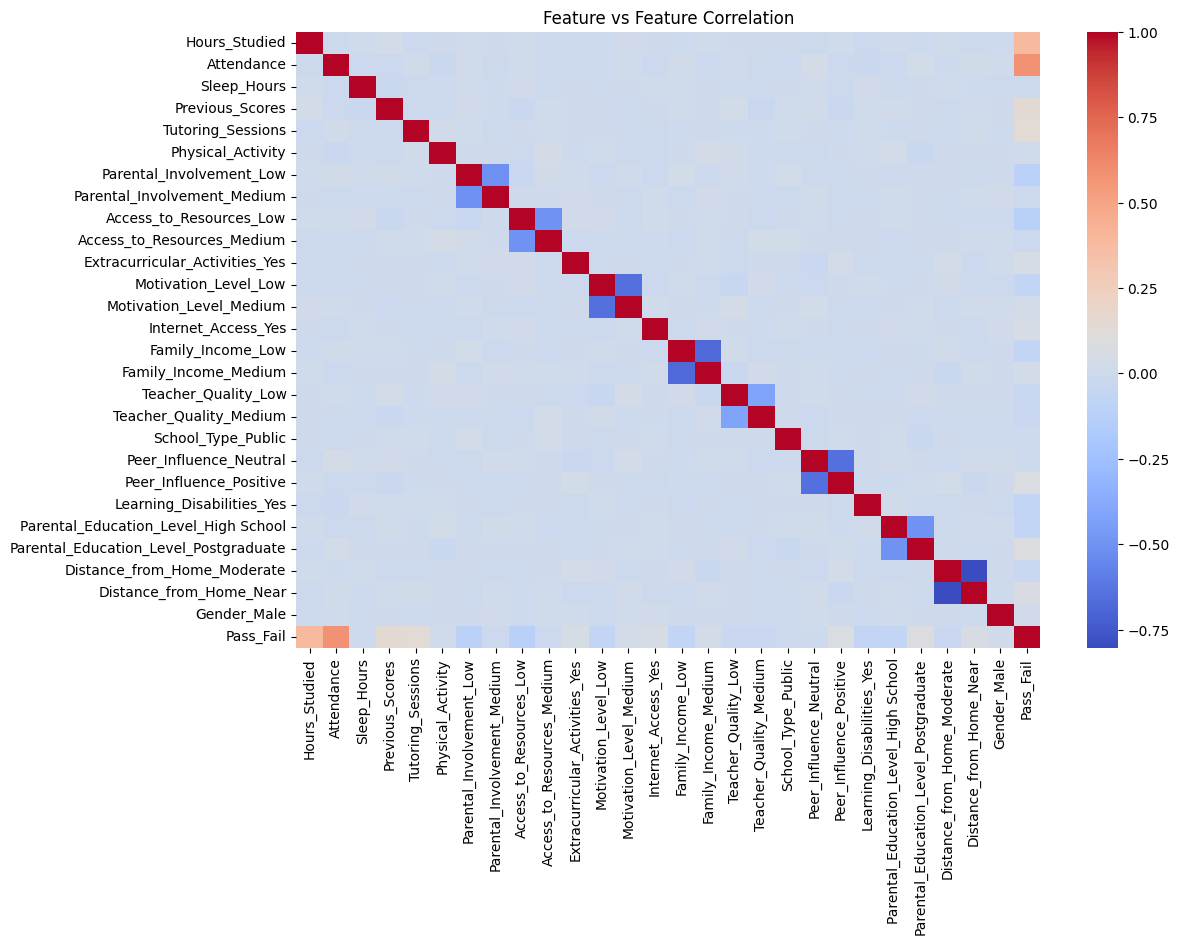

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(features.corr(), cmap="coolwarm")
plt.title("Feature vs Feature Correlation")
plt.show()


In [21]:
print("\nCorrelation with Exam_Score:")
correlation = df_encoded.corr()["Exam_Score"]
print(correlation.sort_values(ascending=False))


Correlation with Exam_Score:
Exam_Score                               1.000000
Pass_Fail                                0.725019
Attendance                               0.581072
Hours_Studied                            0.445455
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Parental_Education_Level_Postgraduate    0.093764
Peer_Influence_Positive                  0.081217
Distance_from_Home_Near                  0.080933
Extracurricular_Activities_Yes           0.064382
Internet_Access_Yes                      0.051475
Physical_Activity                        0.027824
Motivation_Level_Medium                  0.024771
Family_Income_Medium                     0.020995
Gender_Male                             -0.002032
Peer_Influence_Neutral                  -0.007795
School_Type_Public                      -0.008844
Sleep_Hours                             -0.017022
Access_to_Resources_Medium              -0.026158
Parental_Involvement

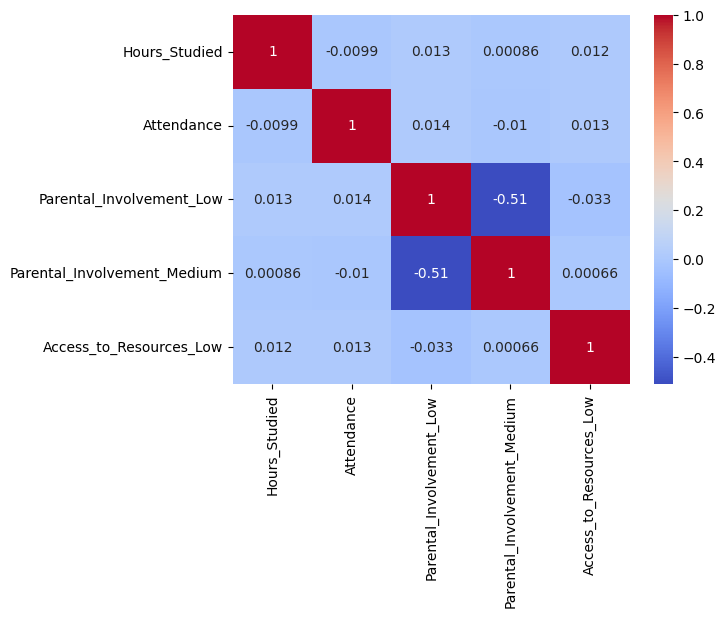

In [22]:
cols1 = ["Hours_Studied", "Attendance", "Parental_Involvement_Low", "Parental_Involvement_Medium", 
         "Access_to_Resources_Low"]
sns.heatmap(df_encoded[cols1].corr(), annot=True, cmap="coolwarm")
plt.show()

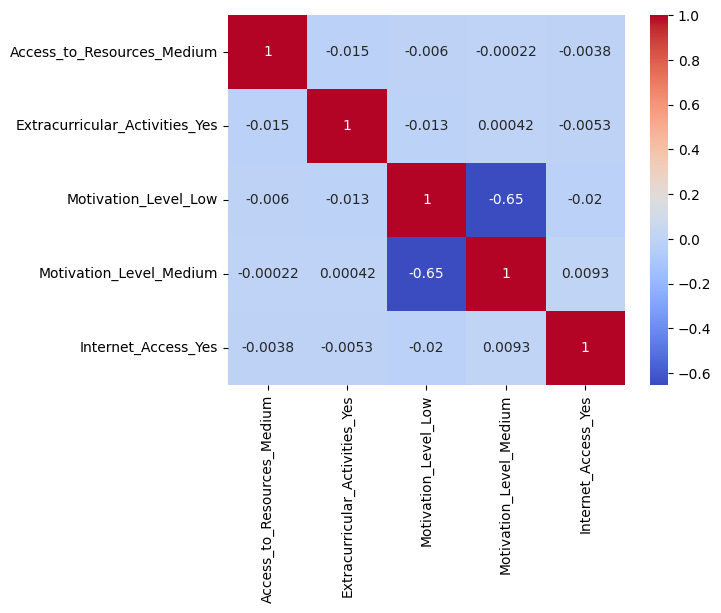

In [23]:
cols2 = ["Access_to_Resources_Medium", "Extracurricular_Activities_Yes", "Motivation_Level_Low",
         "Motivation_Level_Medium", "Internet_Access_Yes"]
sns.heatmap(df_encoded[cols2].corr(), annot=True, cmap="coolwarm")
plt.show()

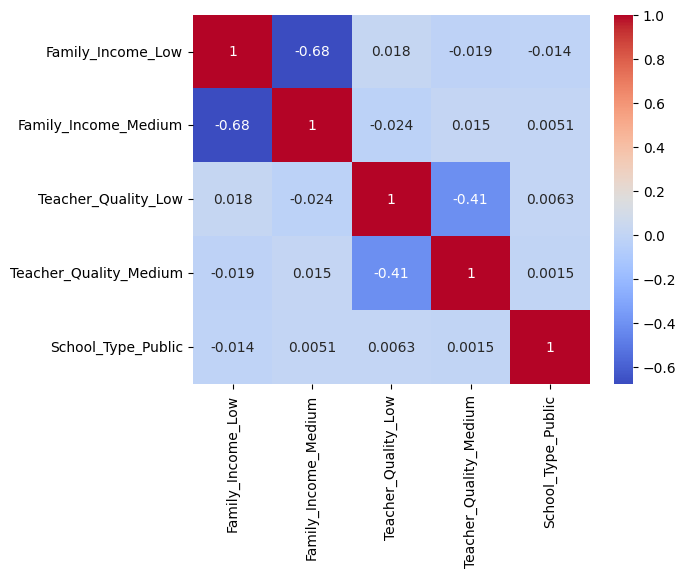

In [24]:
cols3 = ["Family_Income_Low", "Family_Income_Medium", "Teacher_Quality_Low", "Teacher_Quality_Medium",
         "School_Type_Public"]
sns.heatmap(df_encoded[cols3].corr(), annot=True, cmap="coolwarm")
plt.show()

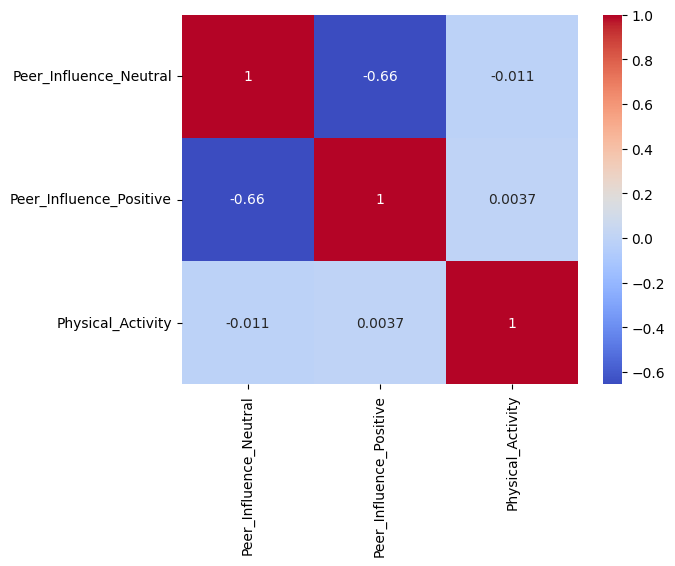

In [25]:
cols4 = ["Peer_Influence_Neutral", "Peer_Influence_Positive", "Physical_Activity"]
sns.heatmap(df_encoded[cols4].corr(), annot=True, cmap="coolwarm")
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df_encoded.drop(["Exam_Score", "Pass_Fail"], axis=1)
import pickle

with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)

# Regression target
y = df_encoded["Exam_Score"]

# Classification target
y_cls = df_encoded["Pass_Fail"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_cls
)

In [28]:
# Align classification target with same split
y_train_cls = y_cls.loc[X_train.index]
y_test_cls = y_cls.loc[X_test.index]

In [29]:
print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (5285, 27)
Test size: (1322, 27)


In [30]:
# CORRELATION FILTER
corr_target = df_encoded.corr()["Exam_Score"].abs().sort_values(ascending=False)

selected_corr = corr_target[corr_target > 0.1].index
selected_corr = selected_corr.drop("Exam_Score")

print("\nCorrelation Selected Features:")
print(selected_corr.tolist())


Correlation Selected Features:
['Pass_Fail', 'Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [31]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
importances = rf.feature_importances_
feature_names = X_train.columns

In [33]:
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

In [34]:
print("\nTop 10 Important Features:")
print(feat_imp.sort_values(ascending=False).head(10))


Top 10 Important Features:
Attendance                        0.388326
Hours_Studied                     0.253139
Previous_Scores                   0.089125
Tutoring_Sessions                 0.035220
Physical_Activity                 0.026321
Sleep_Hours                       0.024443
Parental_Involvement_Low          0.019195
Access_to_Resources_Low           0.019083
Access_to_Resources_Medium        0.009943
Extracurricular_Activities_Yes    0.009856
dtype: float64


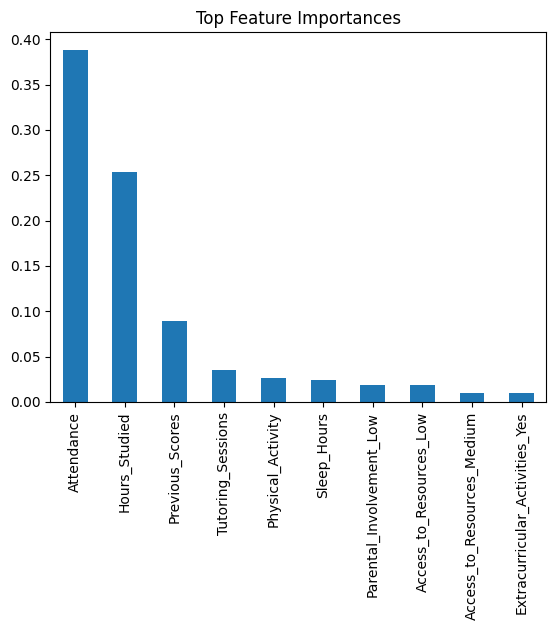

In [35]:
feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

feature_selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42),
    threshold="median"
)


In [37]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

baseline_pred = np.full_like(y_test, y_train.mean())

In [38]:
print("\nBaseline Model:")
print("R2:", round(r2_score(y_test, baseline_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, baseline_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_pred)), 4))


Baseline Model:
R2: -0.0079
MAE: 2.8979
RMSE: 4.0875


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [40]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3,5,7,9]
        }
    },
    "SVM": {
        "model": SVR(),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"]
        }
    }
}


In [41]:
results = []

In [42]:
for name, config in models.items():
    pipe = Pipeline([
        ("scaler", MinMaxScaler()),
        ("feature_selection", feature_selector),
        ("model", config["model"])
    ])

    grid = GridSearchCV(pipe, config["params"], cv=5, scoring="r2")
    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n{name}:")
    print("R2:", round(r2, 4))
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })


Linear Regression:
R2: 0.6646
MAE: 0.8587
RMSE: 2.358

KNN:
R2: 0.3713
MAE: 1.953
RMSE: 3.2283

SVM:
R2: 0.6632
MAE: 0.8639
RMSE: 2.3626


In [43]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nFinal Comparison:")
print(results_df)


Final Comparison:
               Model        R2       MAE      RMSE
0  Linear Regression  0.664565  0.858655  2.358001
2                SVM  0.663247  0.863892  2.362628
1                KNN  0.371258  1.952993  3.228314


In [44]:
best_model_name = results_df.iloc[0]["Model"]

for name, config in models.items():
    if name == best_model_name:
        pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("feature_selection", feature_selector),
    ("model", config["model"])
])
        grid = GridSearchCV(pipe, config["params"], cv=5, scoring="r2")
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        break
y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

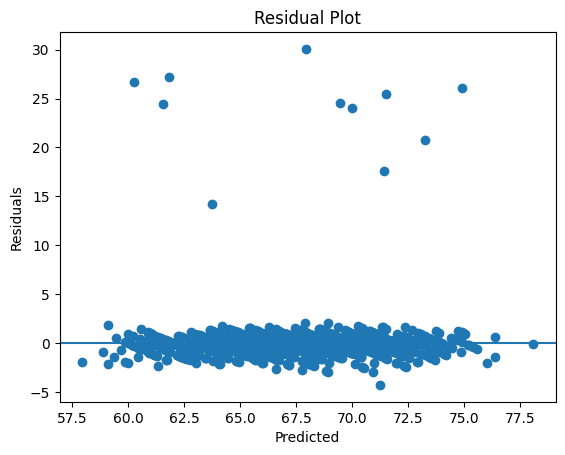

In [45]:
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

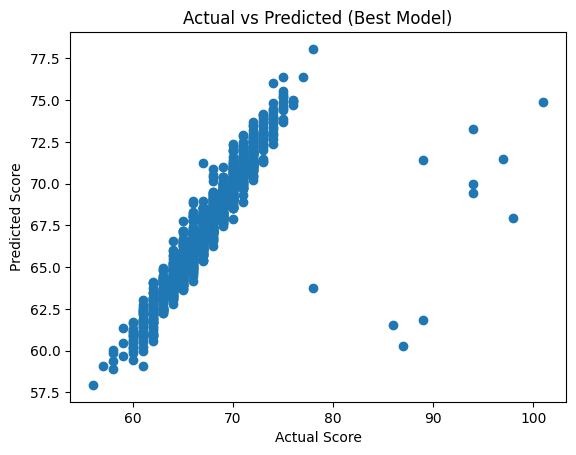

In [46]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted (Best Model)")
plt.show()

In [47]:
# CLASSIFICATION (PASS/FAIL)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [48]:
pipe_cls = Pipeline([
    ("scaler", MinMaxScaler()),
    ("feature_selection", feature_selector),
    ("model", LogisticRegression(max_iter=1000))
])

In [49]:
pipe_cls.fit(X_train, y_train_cls)
y_pred_cls = pipe_cls.predict(X_test)

In [50]:
print("\nClassification Metrics:")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("Precision:", precision_score(y_test_cls, y_pred_cls))
print("Recall:", recall_score(y_test_cls, y_pred_cls))
print("F1:", f1_score(y_test_cls, y_pred_cls))


Classification Metrics:
Accuracy: 0.9220877458396369
Precision: 0.929144385026738
Recall: 0.9328859060402684
F1: 0.9310113864701942


In [51]:
cm = confusion_matrix(y_test_cls, y_pred_cls)

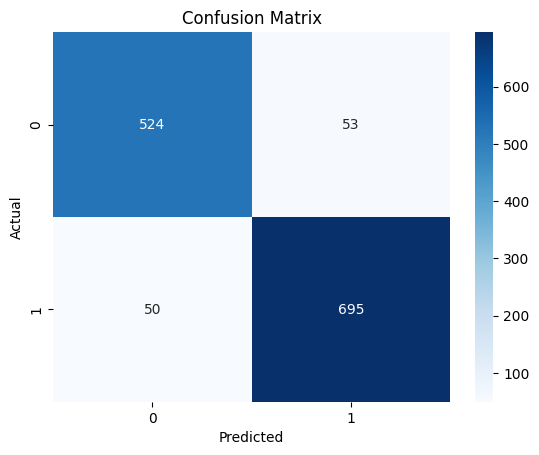

In [52]:
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob_cls = pipe_cls.predict_proba(X_test)[:, 1]

In [54]:
fpr, tpr, thresholds = roc_curve(y_test_cls, y_prob_cls)
roc_auc = roc_auc_score(y_test_cls, y_prob_cls)

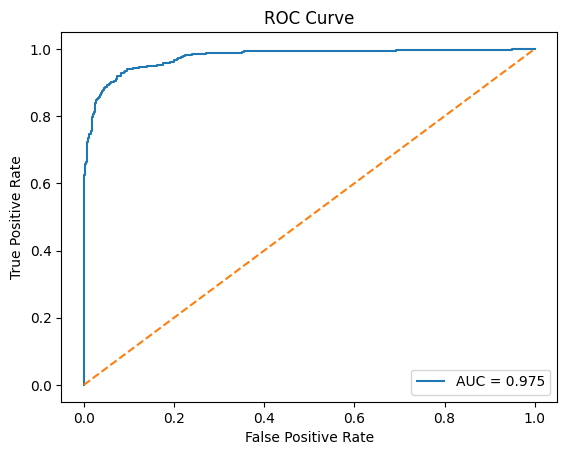

ROC-AUC Score: 0.9754527584241565


In [55]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc)

In [56]:
print(type(best_model))

<class 'sklearn.pipeline.Pipeline'>


In [57]:
best_model = grid.best_estimator_

In [58]:
with open("regression_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [59]:
with open("classification_model.pkl", "wb") as f:
    pickle.dump(pipe_cls, f)